In [1]:
!pip install -q transformers==4.44.2 datasets accelerate evaluate scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 121.0 MB/s eta 0:00:00


In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, auc
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:


BASE_PATH = "/content/drive/MyDrive/Research Code and Data/"
PROCESSED_PATH = BASE_PATH + "data_processed/"
SPLIT_PATH = PROCESSED_PATH + "splits/"
RESULTS_PATH = BASE_PATH + "results/indicbert/"

os.makedirs(RESULTS_PATH, exist_ok=True)

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [11]:
!pip install huggingface_hub
from huggingface_hub import login
login()

In [14]:
MODEL_NAME = "ai4bharat/indic-bert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
MAX_LEN = 128
EPOCHS = 3
LR = 2e-5
BATCH_SIZE = 16

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    acc = accuracy_score(labels, preds)

    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    roc_auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [17]:

def train_on_dataset(dataset_name):

    print(f"\n======== Training IndicBERT on {dataset_name.upper()} ========\n")

    train_df = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_train.csv")
    val_df   = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_val.csv")
    test_df  = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_test.csv")

    def clean_dataframe(df):
        df = df.dropna(subset=["text", "label"])
        df["text"] = df["text"].astype(str)
        df = df[df["text"].str.strip() != ""]
        df = df.reset_index(drop=True)
        return df

    train_df = clean_dataframe(train_df)
    val_df   = clean_dataframe(val_df)
    test_df  = clean_dataframe(test_df)

    train_ds = Dataset.from_pandas(train_df)
    val_ds   = Dataset.from_pandas(val_df)
    test_ds  = Dataset.from_pandas(test_df)

    train_ds = train_ds.map(tokenize_function, batched=True)
    val_ds   = val_ds.map(tokenize_function, batched=True)
    test_ds  = test_ds.map(tokenize_function, batched=True)

    train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=RESULTS_PATH + dataset_name,
        evaluation_strategy="epoch",
        save_strategy="no",
        learning_rate=LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    trainer.train()
    runtime = time.time() - start_time

    print("\nEvaluating on TEST set...\n")
    test_metrics = trainer.evaluate(test_ds)

    # ROC
    predictions = trainer.predict(test_ds)
    logits = predictions.predictions
    labels = predictions.label_ids

    probabilities = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    fpr, tpr, _ = roc_curve(labels, probabilities)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - IndicBERT - {dataset_name}")
    plt.legend()
    plt.show()

    test_metrics["eval_roc_auc"] = roc_auc
    test_metrics["runtime_seconds"] = runtime
    test_metrics["dataset"] = dataset_name

    del trainer
    del model
    torch.cuda.empty_cache()

    return test_metrics


======== Training IndicBERT on THAR ========



Map:   0%|          | 0/8082 [00:00<?, ? examples/s]

Map:   0%|          | 0/1732 [00:00<?, ? examples/s]

Map:   0%|          | 0/1732 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.608600,0.609526,0.672055,0.608319,0.858191,0.711968,0.746615
2,0.552100,0.566904,0.714203,0.663296,0.801956,0.726065,0.776510
3,0.501100,0.571448,0.717090,0.689815,0.728606,0.708680,0.788808



Evaluating on TEST set...



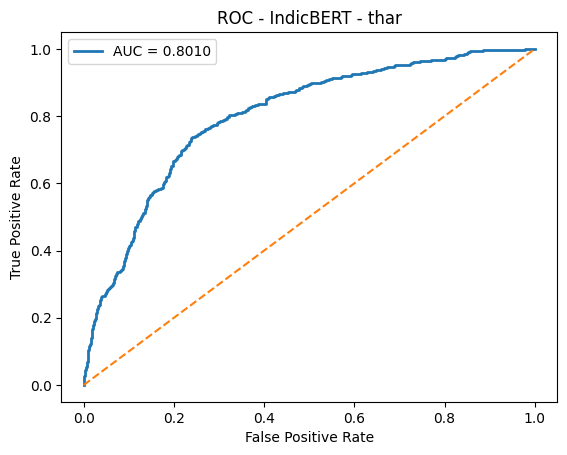


======== Training IndicBERT on HASOC ========



Map:   0%|          | 0/4684 [00:00<?, ? examples/s]

Map:   0%|          | 0/1004 [00:00<?, ? examples/s]

Map:   0%|          | 0/1004 [00:00<?, ? examples/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.639500,0.560416,0.749004,0.723757,0.793939,0.757225,0.774940
2,0.526700,0.541884,0.749004,0.722936,0.795960,0.757692,0.803578
3,0.481700,0.543021,0.755976,0.745098,0.767677,0.756219,0.811073



Evaluating on TEST set...



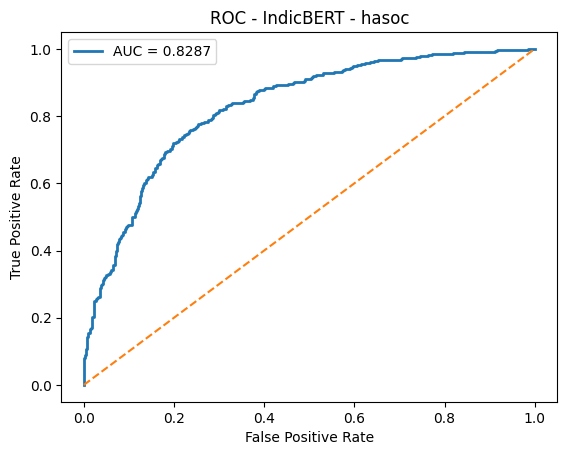


======== Training IndicBERT on AOLD ========



/tmp/ipython-input-507/2429339948.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text"] = df["text"].astype(str)


Map:   0%|          | 0/5641 [00:00<?, ? examples/s]

Map:   0%|          | 0/1209 [00:00<?, ? examples/s]

Map:   0%|          | 0/1210 [00:00<?, ? examples/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.528600,0.525386,0.747725,0.580247,0.526611,0.552129,0.767826
2,0.426800,0.479998,0.766749,0.625418,0.523810,0.570122,0.808110
3,0.341800,0.508888,0.761787,0.610932,0.532213,0.568862,0.808580



Evaluating on TEST set...



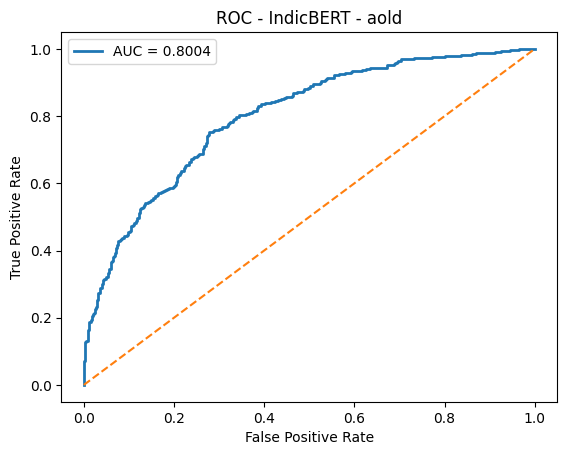


======== Training IndicBERT on COMBINED ========



/tmp/ipython-input-507/2429339948.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text"] = df["text"].astype(str)


Map:   0%|          | 0/18408 [00:00<?, ? examples/s]

Map:   0%|          | 0/3945 [00:00<?, ? examples/s]

Map:   0%|          | 0/3945 [00:00<?, ? examples/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.544500,0.549923,0.711787,0.657801,0.666068,0.661909,0.785084
2,0.490400,0.535800,0.733840,0.687387,0.681628,0.684495,0.811864
3,0.436400,0.536334,0.736122,0.690217,0.684022,0.687106,0.814939



Evaluating on TEST set...



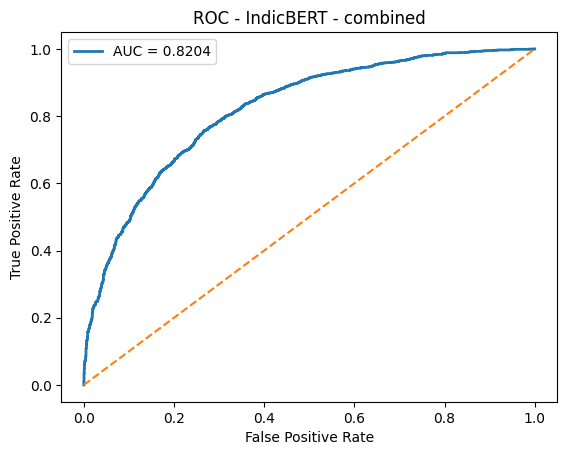

In [18]:
datasets = ["thar", "hasoc", "aold", "combined"]

summary = []

for ds in datasets:
    result = train_on_dataset(ds)
    summary.append(result)



In [19]:
results_df = pd.DataFrame(summary)
results_df.to_csv(RESULTS_PATH + "indicbert_results.csv", index=False)

results_df

,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,runtime_seconds,dataset
0,0.550094,0.744226,0.717265,0.756724,0.736466,0.801045,3.1720,546.030,34.363,3.0,142.713928,thar
1,0.517313,0.759960,0.748047,0.773737,0.760675,0.828672,1.8666,537.883,33.752,3.0,79.783580,hasoc
2,0.525171,0.756198,0.592920,0.561453,0.576758,0.800437,2.2070,548.244,34.435,3.0,95.146831,aold
3,0.530320,0.743473,0.702088,0.684431,0.693147,0.820410,7.1649,550.601,34.474,3.0,311.539403,combined


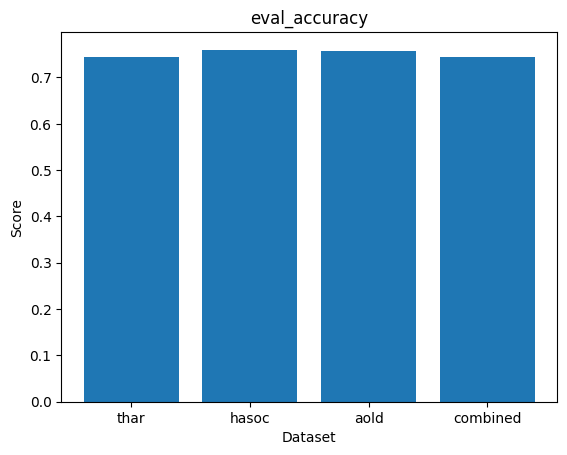

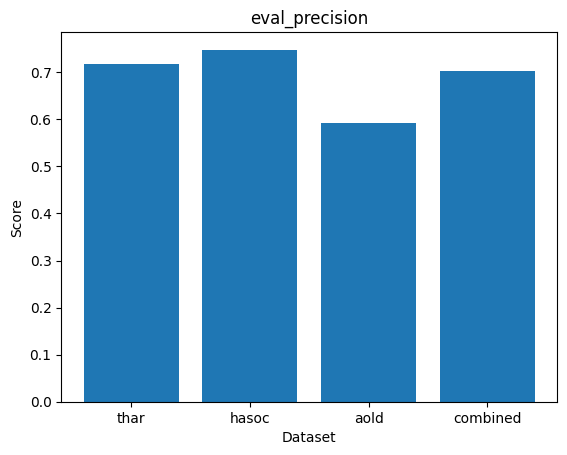

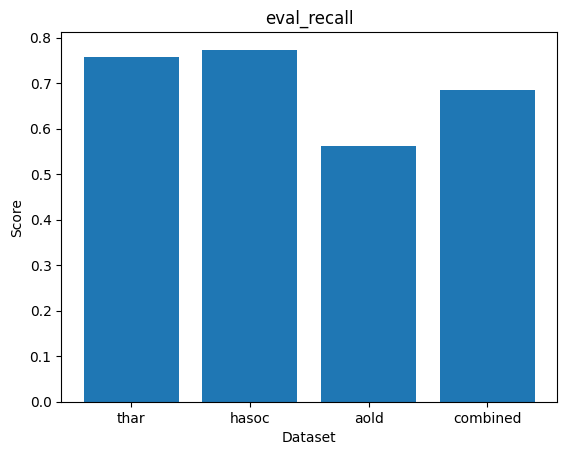

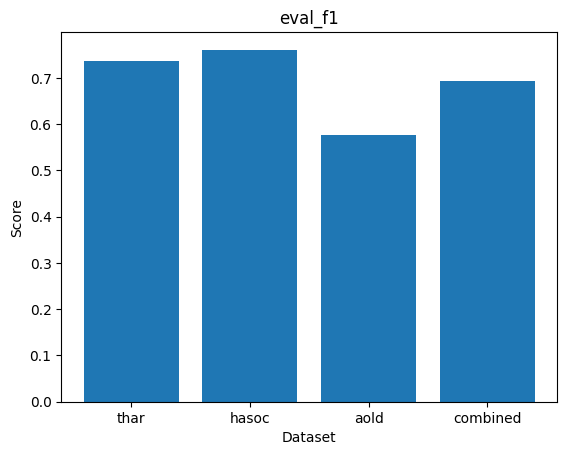

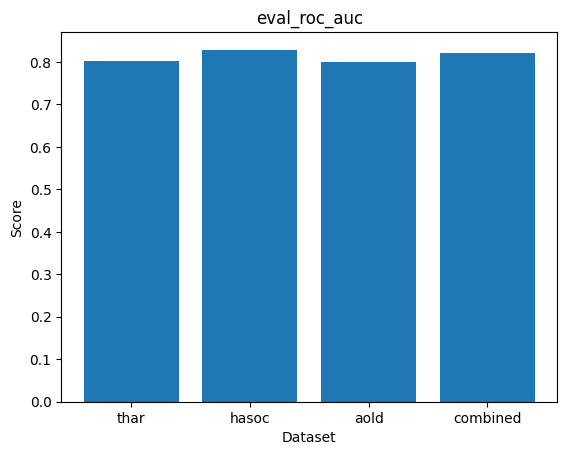

In [20]:
metrics_to_plot = ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1", "eval_roc_auc"]

for metric in metrics_to_plot:
    plt.figure()
    plt.bar(results_df["dataset"], results_df[metric])
    plt.title(metric)
    plt.ylabel("Score")
    plt.xlabel("Dataset")
    plt.show()